In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
import torch.nn as nn
import numpy as np

## Ground Truth Sampling Mathods

In [2]:
def sample(n: int, device = 'cuda') -> torch.Tensor:
    x1 = torch.rand(n) * 4 - 2
    x2 = torch.rand(n) - torch.randint(high=2, size=(n,)) * 2
    x2 = x2 + (torch.floor(x1) % 2)
    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    return data.float().to(device)

def get_interp_dist_gt(source, target, flow_model, t):
    return (1-t) * source + t * target

## Class and Methods for Model

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim+1, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, t, x):
        x = torch.cat([x, t.expand(x.size(0), 1)], dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

### Train

In [4]:
def train_flow_model(model_path = "flow_model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    flow_model = MLP(input_dim=2, hidden_dim=512, output_dim=2).to(device)

    if os.path.exists(model_path):
        print(f"Warning: Overwriting model at ./{model_path}\n")

    optimizer = torch.optim.Adam(flow_model.parameters(), lr=1e-5)
    mse_loss = nn.MSELoss()
    epochs =50000

    for epoch in range(epochs):
        flow_model.train()

        batch_size = 4096
        batch1 = torch.randn(batch_size, 2).to(device) #x_0
        batch2 = sample(batch_size).to(device)  #x_1
        
        t = torch.rand(batch_size, 1).to(device)
        xt = (1 - t) * batch1 + t * batch2
        vt = flow_model(t, xt)
        ut = batch2 - batch1

        loss = mse_loss(vt, ut)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 500 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
            torch.save({
                'epoch': epoch,
                'model_state_dict': flow_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_loss': loss,
            }, model_path)
    torch.save(flow_model.state_dict(), model_path)

### Inference

In [5]:
from torchdiffeq import odeint
from typing import Dict, Optional, List, Callable
def ode_intergrate(ode_func: Callable,
                   init_x: torch.Tensor,
                   ode_opts: Dict = {},
                   method = 'euler10',
                   t_eps: float = 0,
                   init_t: float = 0.,
                   final_t: float = 1.,
                   t_arr: Optional[List[float]] = None,
                   intermediate_points: bool = False
                   ) -> torch.Tensor:
    
    class ODEFunc(torch.nn.Module):
        def __init__(self, ode_func):
            super(ODEFunc, self).__init__()
            self.ode_func = ode_func

        def forward(self, t, x):
            t = torch.ones_like(x[:, 0]) * t
            t = t.view(-1, 1)

            return self.ode_func(t, x)

    if t_arr is None and 'euler' == method:
        t = torch.FloatTensor([init_t-t_eps, final_t]).to(init_x.device)
    elif 'euler' in method:
        num_inference = int(method.split('euler')[-1])
        time_interval = (final_t - (init_t - t_eps)) / num_inference
        t = torch.arange(0, num_inference + 1) * time_interval + (init_t - t_eps)
        t = t.to(init_x.device).float()
        method = 'euler'
    else:
        t = torch.FloatTensor([init_t-t_eps, final_t]).to(init_x.device)

    ode_function = ODEFunc(ode_func)

    z = odeint(ode_function, init_x, t, **
               {"atol": 1e-7, "rtol": 1e-9, "method":method, **ode_opts})
    if not intermediate_points:
        z = z[-1]
    return z

def get_vanilla_trajectory(func, x, steps=1000, reversed=False):
    traj = []
    for i in range(steps+1):
        t = i / steps
        if reversed:
            if t == 0:
                traj.append(x)
                continue
            xt = ode_intergrate(func, x, init_t=1, final_t=1-t)
        else:
            if t == 0:
                traj.append(x)
                continue
            xt = ode_intergrate(func, x, init_t=0, final_t=t)
        traj.append(xt)
    return traj

### Inference: FDS

In [6]:
def divergences(t, flow_model, xt):

    if not xt.is_leaf:
        xt = xt.detach()
    xt = xt.requires_grad_(True)

    if xt.ndim != 2:
        raise ValueError(f"xt must be (B, D). Got {tuple(xt.shape)}")

    B, D = xt.shape
    t_vec = torch.full((B, 1), float(t), device=xt.device, dtype=xt.dtype)

    vt = flow_model(t_vec, xt)
    if vt.shape != xt.shape:
        raise ValueError(f"flow_model must return same shape as xt. "
                         f"Got vt={tuple(vt.shape)}, xt={tuple(xt.shape)}")

    vt_flat = vt.reshape(B, -1)
    div = xt.new_zeros(B)
    for k in range(D):
        grad_x = torch.autograd.grad(
            outputs=vt_flat[:, k].sum(),
            inputs=xt,
            create_graph=True,
            retain_graph=True,
            allow_unused=False,
        )[0]

        div = div + grad_x[:, k]

    return vt_flat, div

def fds_perturb(xt, flow_model, start_t, device = 'cuda',noise_scale=0.04):
    t = start_t
    t_vec = torch.ones(xt.size(0), 1) * t
    t_vec = t_vec.to(device)
    
    xt = xt.detach().requires_grad_(True)
    _, xt_divergence = divergences(t, flow_model, xt)


    noised_xt = xt + torch.randn_like(xt) * noise_scale
    _, noised_xt_divergence = divergences(t, flow_model, noised_xt)
            
    div_mask = noised_xt_divergence.detach() < xt_divergence.detach()
    best_samples = torch.where(div_mask.unsqueeze(1), noised_xt.detach(), xt.detach())

    xt = best_samples
    return xt

def fds_update(xt, flow_model, start_t, end_t, device='cuda',noise_scale=0.04):
    t=start_t
    t_interval = end_t - start_t

    xt = fds_perturb(xt, flow_model, t, device=device, noise_scale=noise_scale)
    xt_next = ode_intergrate(flow_model, xt, init_t=t, final_t=t+t_interval, method='euler1') 

    return xt_next

def get_fds_trajectory(flow_model, xt, steps=1000, reversed=False, device='cuda', noise_scale=0.04):
    traj = []
    for i in range(steps+1):
        if i == 0:
            traj.append(xt)
            continue
        xt = fds_update(xt, flow_model, start_t=i/steps, end_t=(i+1)/steps, device = device, noise_scale=noise_scale)
        traj.append(xt)
    return traj


## 2D Synthetic Experiment

In [7]:
gb_flow_model_name = "flow_model.pth"
train_flow_model(model_path = gb_flow_model_name)

Epoch [500/50000], Loss: 4.4684
Epoch [1000/50000], Loss: 4.3503
Epoch [1500/50000], Loss: 4.1379
Epoch [2000/50000], Loss: 4.0015
Epoch [2500/50000], Loss: 4.0605
Epoch [3000/50000], Loss: 3.8664
Epoch [3500/50000], Loss: 3.8472
Epoch [4000/50000], Loss: 3.8314
Epoch [4500/50000], Loss: 3.7137
Epoch [5000/50000], Loss: 3.8140
Epoch [5500/50000], Loss: 3.8363
Epoch [6000/50000], Loss: 3.8248
Epoch [6500/50000], Loss: 3.6874
Epoch [7000/50000], Loss: 3.8039
Epoch [7500/50000], Loss: 3.7544
Epoch [8000/50000], Loss: 3.7818
Epoch [8500/50000], Loss: 3.7820
Epoch [9000/50000], Loss: 3.7940
Epoch [9500/50000], Loss: 3.8440
Epoch [10000/50000], Loss: 3.8717
Epoch [10500/50000], Loss: 3.7916
Epoch [11000/50000], Loss: 3.8001
Epoch [11500/50000], Loss: 3.8314
Epoch [12000/50000], Loss: 3.7917
Epoch [12500/50000], Loss: 3.7918
Epoch [13000/50000], Loss: 3.8507
Epoch [13500/50000], Loss: 3.7990
Epoch [14000/50000], Loss: 3.7826
Epoch [14500/50000], Loss: 3.7791
Epoch [15000/50000], Loss: 3.8148


In [8]:
import matplotlib.pyplot as plt
import torch
torch.manual_seed(0)

gb_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gb_num_samples = 100_000  
gb_sources = torch.randn(gb_num_samples, 2)
gb_targets = sample(gb_num_samples, device=gb_device)

gb_flow_model = MLP(input_dim=2, hidden_dim=512, output_dim=2).to(gb_device)
gb_flow_model.load_state_dict(torch.load(gb_flow_model_name))

gb_num_trajectories = 10000
gb_num_steps = 20
tmp_start_points = torch.randn((gb_num_trajectories, 2)).to(gb_device)

gb_vanilla_trajectories = get_vanilla_trajectory(gb_flow_model, tmp_start_points, steps=gb_num_steps, reversed=False) 
gb_vanilla_trajectories = torch.stack(gb_vanilla_trajectories, dim=1)

gb_noise =0.03
gb_fds_trajectories = get_fds_trajectory(gb_flow_model, tmp_start_points, steps=gb_num_steps,
                                           reversed=False, device=gb_device, noise_scale=gb_noise)
gb_fds_trajectories = torch.stack(gb_fds_trajectories, dim=1)

print(f"trajectories: {gb_vanilla_trajectories.shape}")
print(f"fds trajectories: {gb_fds_trajectories.shape}")

trajectories: torch.Size([10000, 21, 2])
fds trajectories: torch.Size([10000, 21, 2])


### Visualization

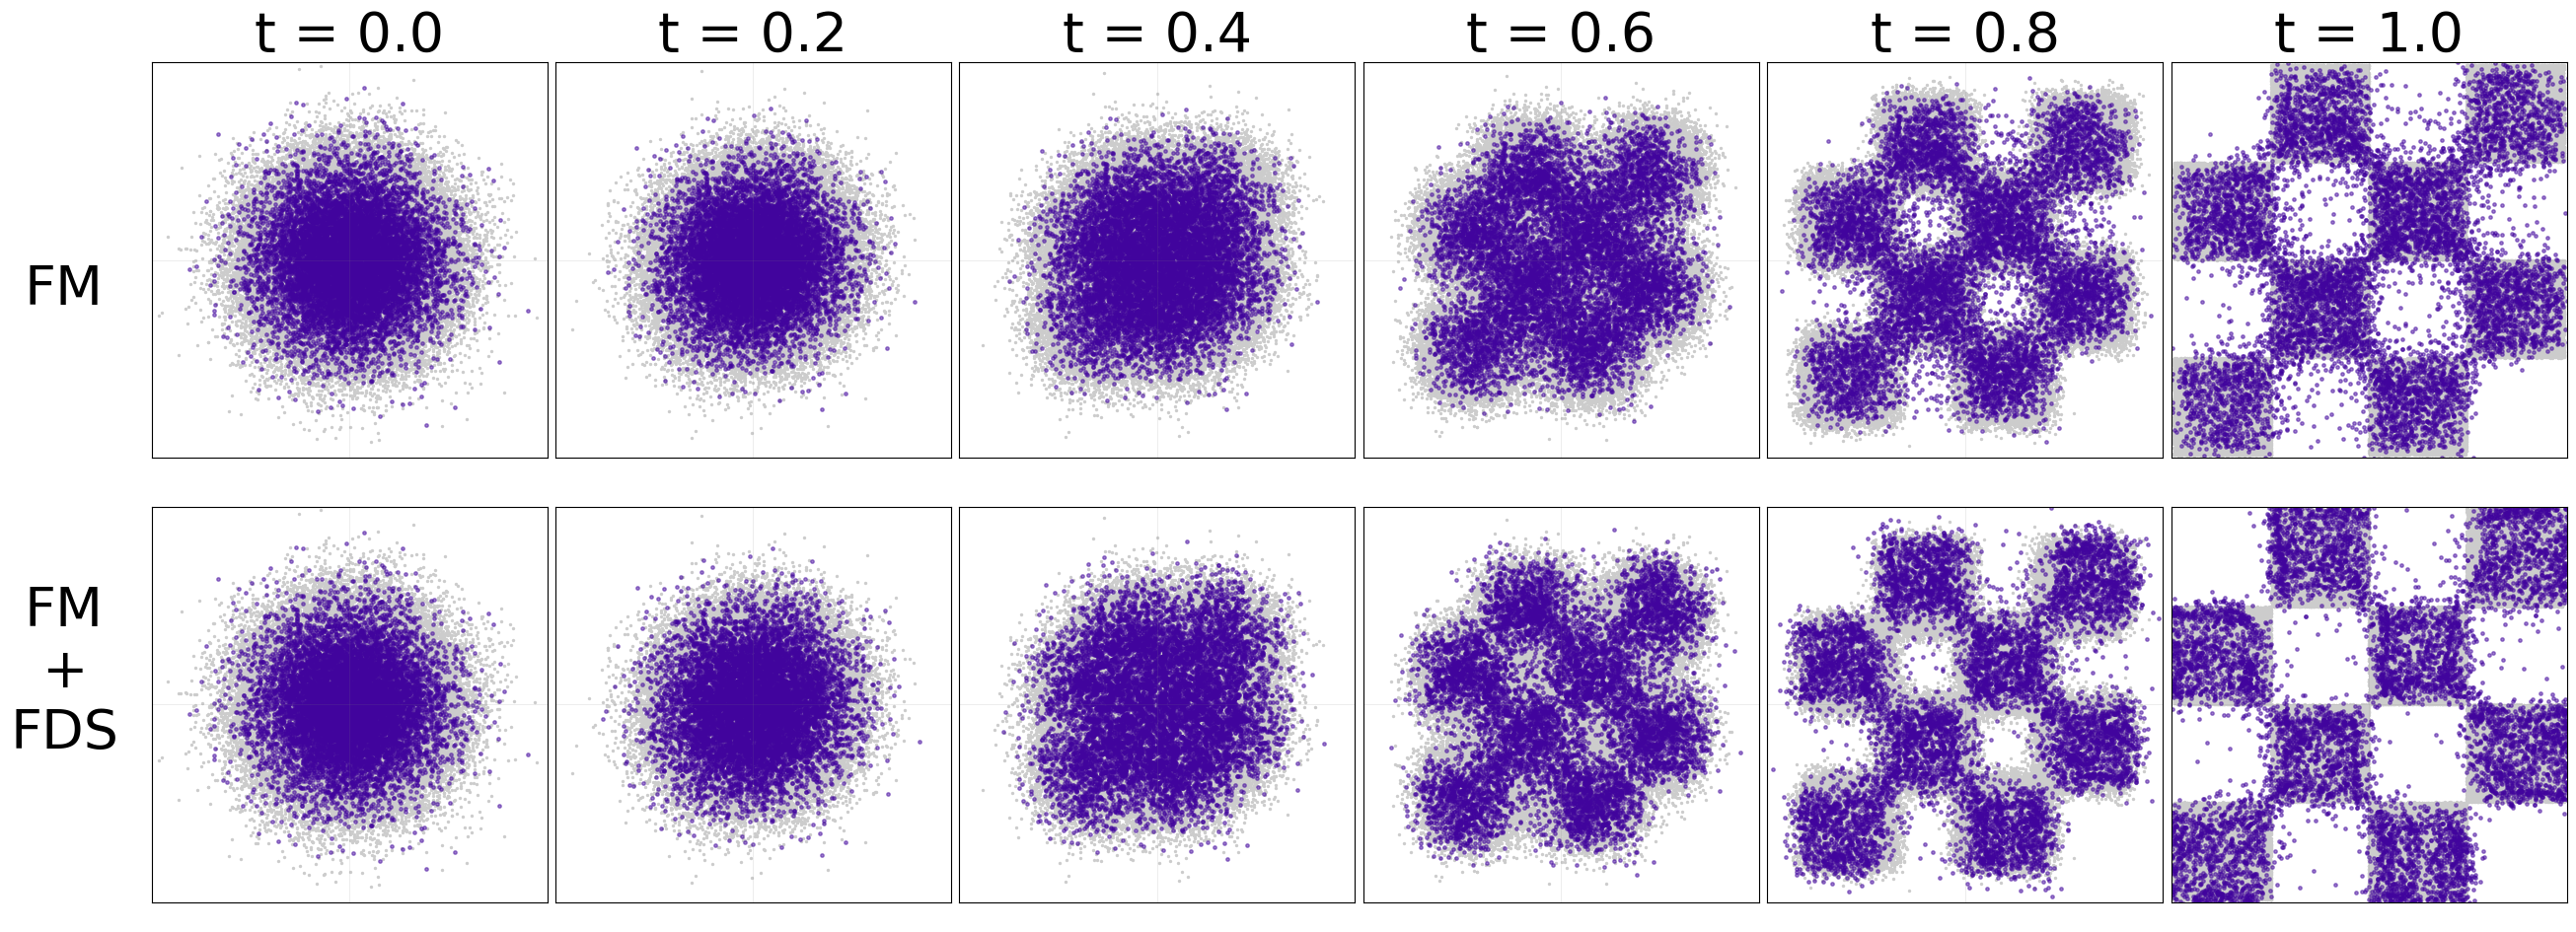

In [10]:
import matplotlib.pyplot as plt
import time

def figure_a(colorcode_div = True, background = 'gt',
             num_plots = 6, device = 'cuda', plot_config=(100000,2,1, 10000, 6, 0.5), bg_color = 'white'):
    assert background in ['gt', 'divergence', 'none'], "background should be either 'gt', 'divergence', or 'none'"

    t_values = np.linspace(0, 1, num_plots)
    trj_step_size = (gb_num_steps+1) // (num_plots-1)
    numdots_gt, s_gt, alpha_gt, numdots_sc, s_sc, alpha_sc = plot_config
    titlesize = 40

    if bg_color != 'white':
        gt_color = 'white'
    else:
        gt_color = '#CCCCCC'


    fig = plt.figure(figsize=(1+25/6*num_plots, 25/6*2*1.12), constrained_layout = True)
    gs = fig.add_gridspec(2, num_plots+1,
                            height_ratios = [1,1],
                            width_ratios = [1]+[5]*num_plots)
    axes = np.array([[fig.add_subplot(gs[r,c]) for c in range(num_plots+1)] for r in range(2)])
    axes[0,0].axis("off")
    axes[1,0].axis("off")
    axes[0,0].text(0,0.4,"FM", ha = 'center',
                   fontsize = titlesize)
    axes[1,0].text(0,0.4,"FM\n+\nFDS", ha = 'center',
                   fontsize = titlesize)

    side = torch.linspace(-4, 4, 50) 
    xx, yy = torch.meshgrid(side, side, indexing='xy')
    grid_points = torch.stack([xx.flatten(), yy.flatten()], dim=1)
    grid_size = 50


    cmap = plt.get_cmap("plasma")
    c=cmap(0.1)
    for row in range(2):
        for i ,t in enumerate(t_values):
            ax = axes[row, i+1]
            _, div = divergences(t, gb_flow_model, grid_points.to(device))
            magnitude = div.detach()
            M_grid = magnitude.view(grid_size, grid_size).cpu().numpy()

            gt_dist = get_interp_dist_gt(gb_sources.to(device), gb_targets.to(device), None, t=t)

            if background == 'divergence':
                bg = ax.imshow(
                    M_grid, 
                    extent=[-4, 4, -4, 4], 
                    origin='lower', 
                    cmap='Blues',        
                    interpolation='bilinear'
                )
            elif background == 'gt':
                bg = ax.scatter(
                    gt_dist[::100000//numdots_gt, 0].detach().cpu().numpy(), 
                    gt_dist[::100000//numdots_gt, 1].detach().cpu().numpy(),
                    alpha= alpha_gt,
                    s=s_gt,
                    color = gt_color
                )


            if row ==0:
                sampled = gb_vanilla_trajectories[::1,i*trj_step_size, :]
            elif row==1:
                sampled = gb_fds_trajectories[::1, i*trj_step_size, :]


            if colorcode_div:
                _, error_at_sampled = divergences(t, gb_flow_model, sampled)
                sampled_magnitude = error_at_sampled.detach()
                c_values = sampled_magnitude.detach().cpu().numpy()

                sc = ax.scatter(sampled[::10000//numdots_sc, 0].detach().cpu().numpy(),
                                sampled[::10000//numdots_sc, 1].detach().cpu().numpy(),
                                alpha=alpha_sc,
                                c=c_values,
                                cmap='plasma',
                                s=6)
            else:
                sc = ax.scatter(sampled[::10000//numdots_sc][:, 0].detach().cpu().numpy(),
                                sampled[::10000//numdots_sc][:, 1].detach().cpu().numpy(),
                                alpha=alpha_sc,
                                color=c,
                                s=s_sc)
                
            ax.tick_params(left=False, bottom=False, labelleft =False, labelbottom=False)
            ax.set_xlim(-4.5, 4.5)
            ax.set_ylim(-4.5, 4.5)
            ax.axhline(0, color='gray', lw=0.5, alpha=0.2)
            ax.axvline(0, color='gray', lw=0.5, alpha=0.2)
            ax.set_aspect('equal') 
            if row == 0:
                ax.set_title(f"t = {t:.1f}", fontsize = titlesize)
            ax.set_facecolor(bg_color)

    plt.show()

figure_a( colorcode_div = False, background = 'gt', plot_config=(100000,2,1, 10000, 6, 0.5) , bg_color = 'white')
